In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from dataset_box.data_loader import *

In [3]:
root_dir = '/local/s3167445/data'
dm = SegmentationDataModule(root_dir, batch_size=2, num_workers=4, transform=None)
dm.setup(stage='test')  # load test dataset

# Detect input channels dynamically
sample_img, _ = dm.test_dataset[0]#val_dataset[0]
in_ch = sample_img.shape[0]  # CHW format
print("Detected input channels:", in_ch)

Detected input channels: 7


In [4]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

from torch.utils.data import DataLoader

temp_ds = dm.test_dataset
temp_loader = DataLoader(temp_ds, batch_size=2, num_workers=4)

cuda


In [5]:
pynas = torch.jit.load('../model_box/saved_models/PNAS_NVIDIA_jetson_AGX_orin.pt', map_location=device)
pynas.to(device)
pynas.eval()

# from model_box.baselines.resnet_baseline.baseline_cnn import *

# resnet = ResNet18UNet(in_channels=7, num_classes=4) 
# resnet.to(device)  
# resnet.eval()
# state_dict = torch.load("../model_box/saved_models/resnet.pt", map_location=device)
# resnet.load_state_dict(state_dict)

# from model_box.baselines.vit_baseline.vit_seg import *

# vit = ViTSegmentation(in_chans=7, num_classes=4)
# vit.to(device)
# vit.eval()
# state_dict = torch.load("../model_box/saved_models/vit.pt", map_location=device)
# vit.load_state_dict(state_dict)

RecursiveScriptModule(
  original_name=GenericUNetNetwork
  (encoder): RecursiveScriptModule(
    original_name=ModuleList
    (0): RecursiveScriptModule(original_name=Dropout)
    (1): RecursiveScriptModule(
      original_name=AvgPool
      (0): RecursiveScriptModule(original_name=AvgPool2d)
    )
    (2): RecursiveScriptModule(
      original_name=ConvSE
      (0): RecursiveScriptModule(
        original_name=ConvBnAct
        (0): RecursiveScriptModule(original_name=Conv2d)
        (1): RecursiveScriptModule(original_name=BatchNorm2d)
        (2): RecursiveScriptModule(original_name=ReLU)
      )
      (1): RecursiveScriptModule(
        original_name=SEBlock
        (avg_pool): RecursiveScriptModule(original_name=AdaptiveAvgPool2d)
        (fc): RecursiveScriptModule(
          original_name=Sequential
          (0): RecursiveScriptModule(original_name=Linear)
          (1): RecursiveScriptModule(original_name=ReLU)
          (2): RecursiveScriptModule(original_name=Linear)
      

In [5]:
def get_predictions(model, dataloader, device="cpu"):
    """
    model: torch model
    returns:
        preds: tensor of predictions
        labels: ground truth tensor
    """
    preds_all = []
    labels_all = []

    model.eval()

    with torch.no_grad():
        for x, y in dataloader:
            x = x.float().to(device)

            if y.ndim == 4:
                y = torch.argmax(y, dim=1)
            y = y.long().to(device)

            labels_all.append(y.cpu())

            logits = model(x)

            # Get predictions
            preds = torch.argmax(logits, dim=1)

            preds_all.append(preds.cpu())

    if len(labels_all) == 0:
        raise ValueError("Dataloader produced no batches!")

    preds = torch.cat(preds_all)
    labels = torch.cat(labels_all)

    return preds, labels

In [20]:
from evaluation_box.evaluation_functions import *

models = {
    "PyNAS": pynas,
    "ResNet": resnet,
    "ViT": vit
}

results = {"SNR": []}
for name in models:
    results[f"{name}_mIoU"] = []
    results[f"{name}_consistency"] = []


temp_ds = dm.test_dataset
temp_loader = DataLoader(temp_ds, batch_size=2, num_workers=4)

preds = {}
labels = []

for name, model in models.items():
    preds[name], labels = get_predictions(model, temp_loader, device=device)

#print(preds["ViT"])

In [21]:
import importlib
import evaluation_box.evaluation_functions 
importlib.reload(evaluation_box.evaluation_functions)
from evaluation_box.evaluation_functions  import *

for model in models:
    print(compute_miou_(preds=preds[model], labels=labels))

0.858401358127594
0.8734375238418579
0.8914546370506287


               PyNAS    ResNet       ViT
sample_idx                              
0           0.777107  0.691010  0.871585
1           0.806494  0.784756  0.827656
2           0.656221  0.821013  0.586663
3           0.912616  0.891725  0.677120
4           0.633355  0.660618  0.796912


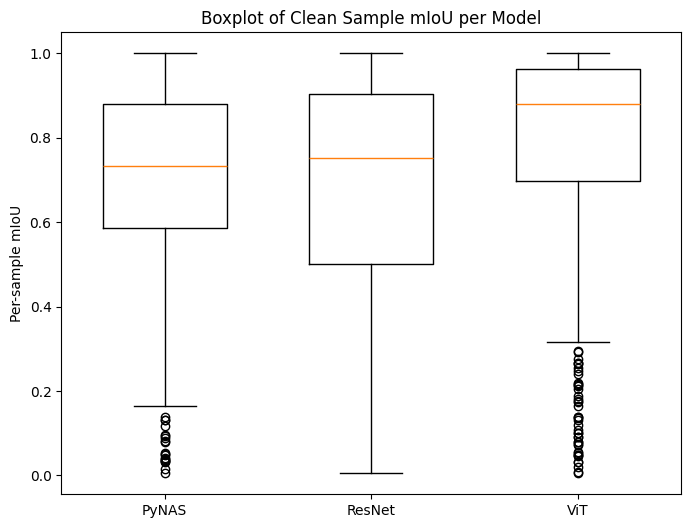

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

miou_per_model = {}
sample_miou_dict = {}

for name in models:
    miou_per_model[name] = compute_miou_per_sample(preds[name], labels).cpu().numpy()


n_samples = len(labels)
for i in range(n_samples):
    sample_miou_dict[i] = {name: float(miou_per_model[name][i]) for name in models}


sample_miou_df = pd.DataFrame.from_dict(sample_miou_dict, orient="index")
sample_miou_df.index.name = "sample_idx"

print(sample_miou_df.head())


plt.figure(figsize=(8,6))
for name in models:
    miou_clean = compute_miou_per_sample(preds[name], labels)
    plt.boxplot(miou_clean.numpy(), positions=[list(models.keys()).index(name)], widths=0.6)
plt.xticks(range(len(models)), list(models.keys()))
plt.ylabel("Per-sample mIoU")
plt.title("Boxplot of Clean Sample mIoU per Model")
plt.show()

In [10]:
import importlib
# import evaluation_box.evaluation_functions 
# importlib.reload(evaluation_box.evaluation_functions)

import dataset_box.perturbation_methods.snr_perturbations
importlib.reload(dataset_box.perturbation_methods.snr_perturbations)
from dataset_box.perturbation_methods.snr_perturbations import *
def perturbed_generator(experiment="SNR", values=None, dataloader=None):
    if experiment == "brightness":
        alpha = values["alpha"]
        optics = OpticalSystem('sentinel', M_b_n_TGT=0.2, SNR=1, l_ref=1.0)
        for images, masks in dataloader:
            images_np = images.numpy()  # (B, C, H, W)
            perturbed_images_np = np.zeros_like(images_np, dtype=np.float32)

            for b in range(images_np.shape[0]):
                img = images_np[b]  # (C, H, W)
                perturbed_images_np[b] = optics.apply_brightness(
                    img,
                    alpha=alpha,
                    clip_range=None,   # or (0, 1) if your data are normalized reflectances
                )

            yield torch.from_numpy(perturbed_images_np).float(), masks
    if experiment == "SNR":
        optics = OpticalSystem('sentinel', values['mtf'], SNR=values['snr'], l_ref=1.0)
        for images, masks in dataloader:
            images_np = images.numpy()             # (B, C, H, W)
            perturbed_images_np = np.zeros_like(images_np)

            for b in range(images_np.shape[0]):    
                img = images_np[b]                 # (C, H, W)
                # Apply SNR per channel 
                for c in range(img.shape[0]):
                    perturbed_images_np[b, c] = optics.apply(img[c], normalize=True)

            yield torch.from_numpy(perturbed_images_np).float(), masks

In [18]:
import importlib
import evaluation_box.evaluation_functions 
importlib.reload(evaluation_box.evaluation_functions)
from evaluation_box.evaluation_functions  import *


experiment = "SNR"
SNR_start = 174
SNR_last = 1
SNR_levels = np.linspace(SNR_start, SNR_last, 10)
tgt_mtf = 0.3

SNR_levels = SNR_levels[::-1]
print(SNR_levels)


for snr_val in SNR_levels:
    values = {"mtf": tgt_mtf, "snr": snr_val}
    print(f"\nEvaluating SNR: {snr_val:.2f}")
    
    
    perturbed_data = list(perturbed_generator(experiment=experiment, values=values, dataloader=temp_loader))

    print(f"Generated perturbed data for snr {snr_val}")

    results["SNR"].append(snr_val)


    for model in models:


        perturbed_preds, _ = get_predictions(models[model], perturbed_data, device=device)

        miou = compute_miou_(perturbed_preds, labels)
        consistency = compute_prediction_consistency_(preds[model], perturbed_preds)
        miou_per_sample = compute_miou_per_sample(perturbed_preds, labels)
        stats = compute_stats_and_outliers(miou_per_sample)

        print(
            f"Model {model} | "
            f"mIoU: {miou:.4f} | "
            f"Consistency: {consistency:.4f} | "
            f"Std: {stats['std']:.4f} | "
            f"Outliers: {len(stats['outliers'])}"
        )
    


[  1.          20.22222222  39.44444444  58.66666667  77.88888889
  97.11111111 116.33333333 135.55555556 154.77777778 174.        ]

Evaluating SNR: 1.00
Generated perturbed data for snr 1.0
Model PyNAS | mIoU: 0.6898 | Consistency: 0.8318 | Std: 0.2545 | Outliers: 449

Evaluating SNR: 20.22
Generated perturbed data for snr 20.22222222222223
Model PyNAS | mIoU: 0.8526 | Consistency: 0.9795 | Std: 0.2090 | Outliers: 9

Evaluating SNR: 39.44
Generated perturbed data for snr 39.44444444444446
Model PyNAS | mIoU: 0.8567 | Consistency: 0.9916 | Std: 0.2049 | Outliers: 16

Evaluating SNR: 58.67
Generated perturbed data for snr 58.66666666666667
Model PyNAS | mIoU: 0.8573 | Consistency: 0.9951 | Std: 0.2035 | Outliers: 16

Evaluating SNR: 77.89


KeyboardInterrupt: 

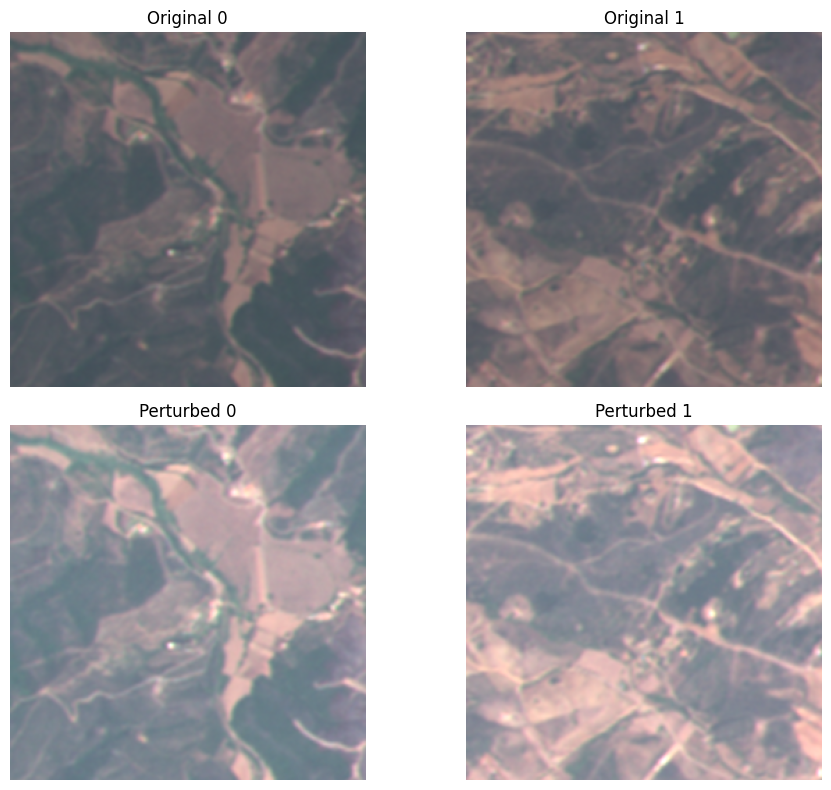

In [71]:
import matplotlib.pyplot as plt
import numpy as np

def plot_before_after(temp_loader, experiment, values, num_images=2):

    # ---- Original images ----
    orig_images, _ = next(iter(temp_loader))
    orig_images = orig_images.numpy()

    # ---- Generate perturbed images ----
    perturbed_data = list(
        perturbed_generator(
            experiment=experiment,
            values=values,
            dataloader=temp_loader
        )
    )

    pert_images, _ = perturbed_data[0]
    pert_images = pert_images.numpy()

    num_images = min(num_images, orig_images.shape[0])

    fig, axes = plt.subplots(2, num_images, figsize=(5 * num_images, 8))

    if num_images == 1:
        axes = np.expand_dims(axes, axis=1)

    for i in range(num_images):

        # --- Original ---
        orig = orig_images[i]
        orig_rgb = np.stack([
            orig[2],  # B04
            orig[1],  # B03
            orig[0],  # B02
        ], axis=-1)

        # --- Perturbed ---
        pert = pert_images[i]
        pert_rgb = np.stack([
            pert[2],
            pert[1],
            pert[0],
        ], axis=-1)

        # clip for visualization
        orig_rgb = np.clip(orig_rgb, 0, 1)
        pert_rgb = np.clip(pert_rgb, 0, 1)

        axes[0, i].imshow(orig_rgb)
        axes[0, i].set_title(f"Original {i}")
        axes[0, i].axis("off")

        axes[1, i].imshow(pert_rgb)
        axes[1, i].set_title(f"Perturbed {i}")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()


values = {"alpha": 1.5}
plot_before_after(temp_loader, experiment="brightness", values=values)


In [24]:
experiment = "brightness"
results = {}
results["brightness"] = []
brightness_levels = [1, 0.95, 0.9, 0.85, 0.8, 1.05, 1.1, 1.15, 1.2]
print(brightness_levels)

for alpha in brightness_levels:
    values = {"alpha": alpha}
    print(f"\nEvaluating brightness alpha: {alpha:.2f}")

    perturbed_data = list(
        perturbed_generator(
            experiment=experiment,
            values=values,
            dataloader=temp_loader
        )
    )

    print(f"Generated perturbed data for brightness alpha {alpha:.2f}")

    results["brightness"].append(alpha)

    for model in models:


        perturbed_preds, _ = get_predictions(models[model], perturbed_data, device=device)

        miou = compute_miou_(perturbed_preds, labels)

        consistency = compute_prediction_consistency_(preds[model], perturbed_preds)

        miou_per_sample = compute_miou_per_sample(perturbed_preds, labels)
  
        stats = compute_stats_and_outliers(miou_per_sample)

        print(
            f"Model {model} | "
            f"mIoU: {miou:.4f} | "
            f"Consistency: {consistency:.4f} | "
            f"Std: {stats['std']:.4f} | "
            f"Outliers: {len(stats['outliers'])}"
        )

[1, 0.95, 0.9, 0.85, 0.8, 1.05, 1.1, 1.15, 1.2]

Evaluating brightness alpha: 1.00
Generated perturbed data for brightness alpha 1.00
Model PyNAS | mIoU: 0.8584 | Consistency: 1.0000 | Std: 0.2009 | Outliers: 20
Model ResNet | mIoU: 0.8734 | Consistency: 1.0000 | Std: 0.2068 | Outliers: 0
Model ViT | mIoU: 0.8915 | Consistency: 1.0000 | Std: 0.2009 | Outliers: 43

Evaluating brightness alpha: 0.95
Generated perturbed data for brightness alpha 0.95
Model PyNAS | mIoU: 0.7800 | Consistency: 0.9213 | Std: 0.2271 | Outliers: 1
Model ResNet | mIoU: 0.8197 | Consistency: 0.9242 | Std: 0.2218 | Outliers: 0
Model ViT | mIoU: 0.8381 | Consistency: 0.9451 | Std: 0.2163 | Outliers: 0

Evaluating brightness alpha: 0.90
Generated perturbed data for brightness alpha 0.90
Model PyNAS | mIoU: 0.6034 | Consistency: 0.8007 | Std: 0.2883 | Outliers: 0
Model ResNet | mIoU: 0.6774 | Consistency: 0.8256 | Std: 0.2729 | Outliers: 0
Model ViT | mIoU: 0.7309 | Consistency: 0.8769 | Std: 0.2580 | Outliers: 0

E